In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
jobs = [
    "Data Scientist with Python machine learning deep learning NLP",
    "Machine Learning Engineer with TensorFlow PyTorch model deployment",
    "Data Analyst with SQL Excel Power BI data visualization",
    "Software Engineer with Java backend APIs system design microservices",
    "Frontend Developer with React JavaScript UI UX design",
    "Full Stack Developer React Node MongoDB web development",
    "DevOps Engineer with Docker Kubernetes CI CD AWS cloud",
    "Cloud Engineer AWS Azure infrastructure deployment networking",
    "Cybersecurity Analyst ethical hacking network security SIEM tools",
    "Penetration Tester vulnerability assessment Kali Linux security",
    "Data Engineer ETL pipelines big data Hadoop Spark SQL",
    "AI Engineer NLP computer vision deep learning Python",
    "Product Manager agile scrum roadmap stakeholder management",
    "UI UX Designer Figma prototyping user research design systems",
    "Backend Developer Python Django REST API development"
]


In [ ]:
df = pd.DataFrame(jobs, columns=["description"])


In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["clean_text"] = df["description"].apply(preprocess)

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df["clean_text"])


In [ ]:
lsa = TruncatedSVD(n_components=5)
X_lsa = lsa.fit_transform(X)


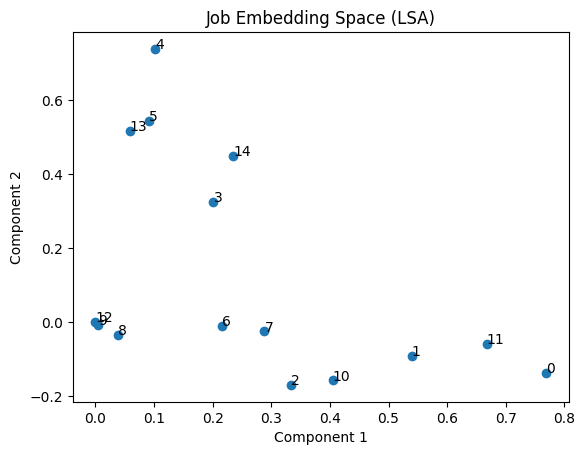

In [ ]:
plt.figure()
plt.scatter(X_lsa[:, 0], X_lsa[:, 1])

for i, txt in enumerate(df["description"]):
    plt.annotate(str(i), (X_lsa[i, 0], X_lsa[i, 1]))

plt.title("Job Embedding Space (LSA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


In [ ]:
candidate = input("Enter your skills/profile: ")
candidate_clean = preprocess(candidate)

candidate_vec = tfidf.transform([candidate_clean])
candidate_lsa = lsa.transform(candidate_vec)

Enter your skills/profile: Python machine learning data analysis pandas numpy


In [ ]:
similarity_scores = cosine_similarity(candidate_lsa, X_lsa)[0]

In [ ]:
top_k = 5
top_indices = np.argsort(similarity_scores)[::-1][:top_k]

print("\nTop Job Recommendations:\n")

for rank, i in enumerate(top_indices, start=1):
    print(f"Rank {rank}:")
    print("Job:", df.iloc[i]["description"])
    print("Similarity Score:", round(similarity_scores[i], 3))
    print("-" * 50)



Top Job Recommendations:

Rank 1:
Job: Data Scientist with Python machine learning deep learning NLP
Similarity Score: 0.973
--------------------------------------------------
Rank 2:
Job: AI Engineer NLP computer vision deep learning Python
Similarity Score: 0.885
--------------------------------------------------
Rank 3:
Job: Machine Learning Engineer with TensorFlow PyTorch model deployment
Similarity Score: 0.723
--------------------------------------------------
Rank 4:
Job: Data Engineer ETL pipelines big data Hadoop Spark SQL
Similarity Score: 0.513
--------------------------------------------------
Rank 5:
Job: Data Analyst with SQL Excel Power BI data visualization
Similarity Score: 0.456
--------------------------------------------------


In [ ]:
result_df = pd.DataFrame({
    "Job": df["description"],
    "Score": similarity_scores
}).sort_values(by="Score", ascending=False)

print("\nAll Jobs Ranked:\n")
print(result_df)


All Jobs Ranked:

                                                  Job         Score
0   Data Scientist with Python machine learning de...  9.733463e-01
11  AI Engineer NLP computer vision deep learning ...  8.852153e-01
1   Machine Learning Engineer with TensorFlow PyTo...  7.230111e-01
10  Data Engineer ETL pipelines big data Hadoop Sp...  5.131351e-01
2   Data Analyst with SQL Excel Power BI data visu...  4.558199e-01
14  Backend Developer Python Django REST API devel...  2.287736e-01
3   Software Engineer with Java backend APIs syste...  1.572210e-01
8   Cybersecurity Analyst ethical hacking network ...  1.521806e-01
7   Cloud Engineer AWS Azure infrastructure deploy...  1.770226e-02
5   Full Stack Developer React Node MongoDB web de...  1.211424e-02
9   Penetration Tester vulnerability assessment Ka...  8.087282e-04
12  Product Manager agile scrum roadmap stakeholde... -2.424545e-17
4   Frontend Developer with React JavaScript UI UX... -1.300006e-02
13  UI UX Designer Figma prot